Dataset Shape: (1470, 36)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2



--- Missing Values Check ---
0

--- Attrition Distribution (%) ---
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


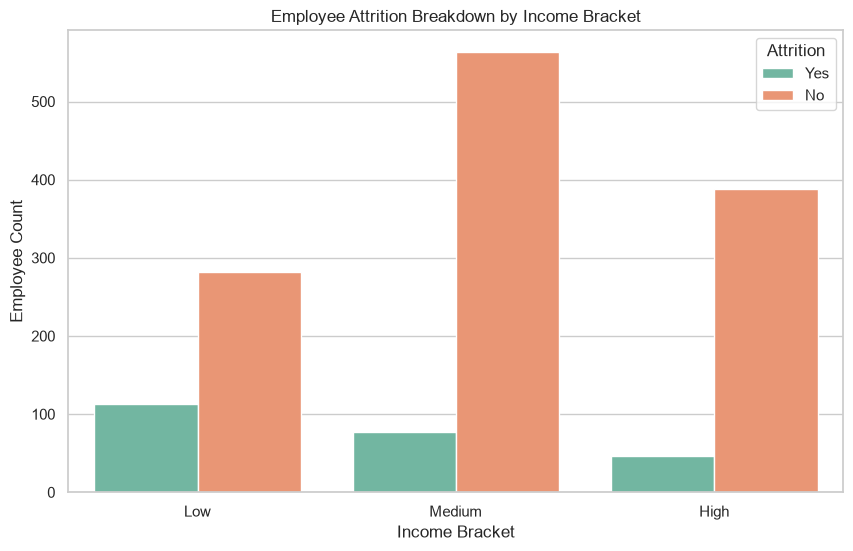

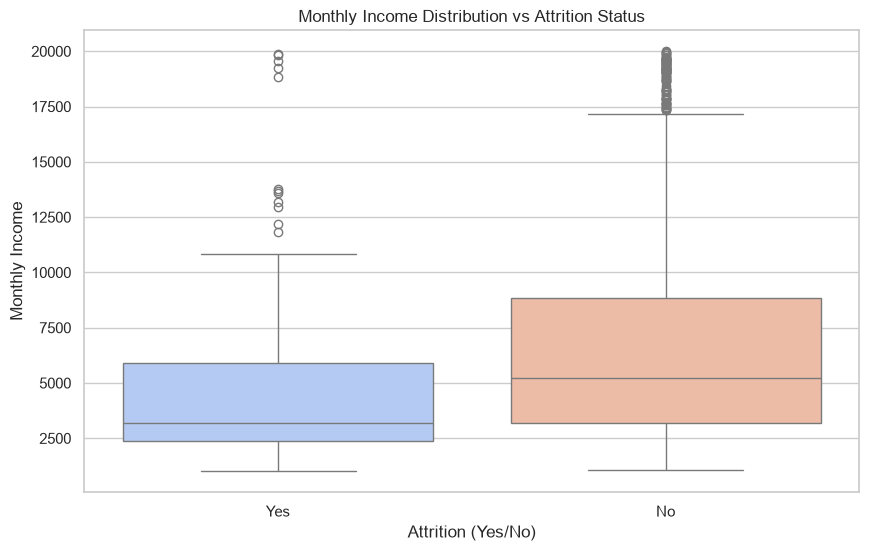

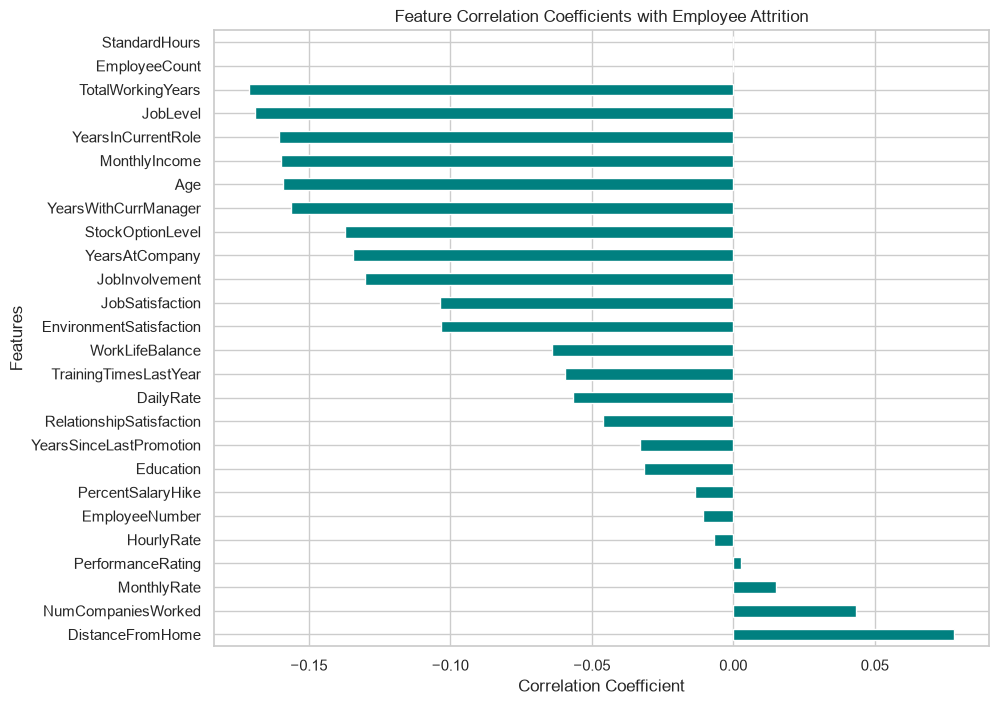

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('Employee attrition data.csv')
print("Dataset Shape:", df.shape)
display(df.head())
print("\n--- Missing Values Check ---")
print(df.isnull().sum().sum())
print("\n--- Attrition Distribution (%) ---")
print(df['Attrition'].value_counts(normalize=True) * 100)
#visualisation 1......
plt.figure()
sns.countplot(
    data=df, 
    x='Income_Bracket', 
    hue='Attrition', 
    order=['Low', 'Medium', 'High'], 
    palette='Set2'
)
plt.title('Employee Attrition Breakdown by Income Bracket')
plt.xlabel('Income Bracket')
plt.ylabel('Employee Count')
plt.show()

# Visualization 2......
plt.figure()
sns.boxplot(
    data=df, 
    x='Attrition', 
    y='MonthlyIncome', 
    hue='Attrition', 
    legend=False, 
    palette='coolwarm'
)
plt.title('Monthly Income Distribution vs Attrition Status')
plt.xlabel('Attrition (Yes/No)')
plt.ylabel('Monthly Income')
plt.show()

df['Attrition_Numeric'] = df['Attrition'].map({'Yes': 1, 'No': 0})
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
attrition_corr = correlation_matrix['Attrition_Numeric'].sort_values(ascending=False)

# Visualization 3......
plt.figure(figsize=(10, 8))
attrition_corr.drop('Attrition_Numeric').plot(kind='barh', color='teal')
plt.title('Feature Correlation Coefficients with Employee Attrition')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.show()